# Gåshamna Bone Distribution Analysis: Documentation

## 1. Overview
This script is designed for the spatial analysis of archaeological bone finds at the **Gåshamna** site. Its primary goal is to transform individual point data into a statistically relevant **hexagonal binning grid**. This method reveals density "hotspots" of find concentrations that are often invisible in a simple point map.

### Why Hexagonal Binning?
Unlike square grids, hexagons reduce sampling bias caused by edge effects of the grid shape and provide a more "natural" visualization of clusters, as the distance between the center of a hexagon and all its neighbors is equidistant.

---

## 2. Technical Features

### Fixed-Scale Alignment
The most critical feature of this script is the use of a **global spatial extent**.

* **The Problem:** Usually, hexbin functions "shrink-wrap" the grid around the points. If you have only a few finds in one corner (e.g., Polar Bear), the hexagons would be shaped differently or sized inconsistently compared to the Whale finds.
* **The Solution:** This script calculates the total bounding box of **all** finds first and forces every single species map to use this exact same template. This ensures that the hexagons in all layers are **perfectly aligned** and can be overlaid in a GIS (like QGIS or ArcGIS) without any offset or scale mismatch.

### Statistical Noise Reduction
The script includes a frequency filter (`min_individuals = 5`). Species with very low find counts are excluded from the individual analysis to prevent misleading interpretations of isolated, random finds that do not represent a significant spatial pattern.

### Native Geometry Extraction
Instead of manually calculating hexagon vertices (which often leads to rounding errors and overlapping edges), this script extracts the mathematical **"paths"** directly from the plotting engine's internal representation.
* **Result:** This ensures a **100% gap-free grid** where cells touch precisely at the edges, preventing the visual artifacts and overlaps often seen in manual geometric constructions.

---

## 3. Implementation Details
The script follows a rigorous workflow to ensure data integrity:
1.  **Data Ingestion:** Reads point geometries from a GeoPackage (.gpkg).
2.  **Normalization:** Identifies species categories and calculates the master extent.
3.  **Processing:** Iterates through filtered species and generates the hexagonal geometry.
4.  **Export:** Writes each result as a separate layer into a final GeoPackage, ready for professional cartographic use.

---

## 4. Usage Tips
* **Resolution:** Adjust the `grid_res` variable to change the size of the hexagons. A higher value results in smaller, more detailed cells.
* **Visualization:** The output uses a high-contrast color scheme (e.g., 'YlOrRd' or 'Reds') to clearly differentiate between high and low density areas against a neutral background.

Success: Analysis with uniform scaling finished.


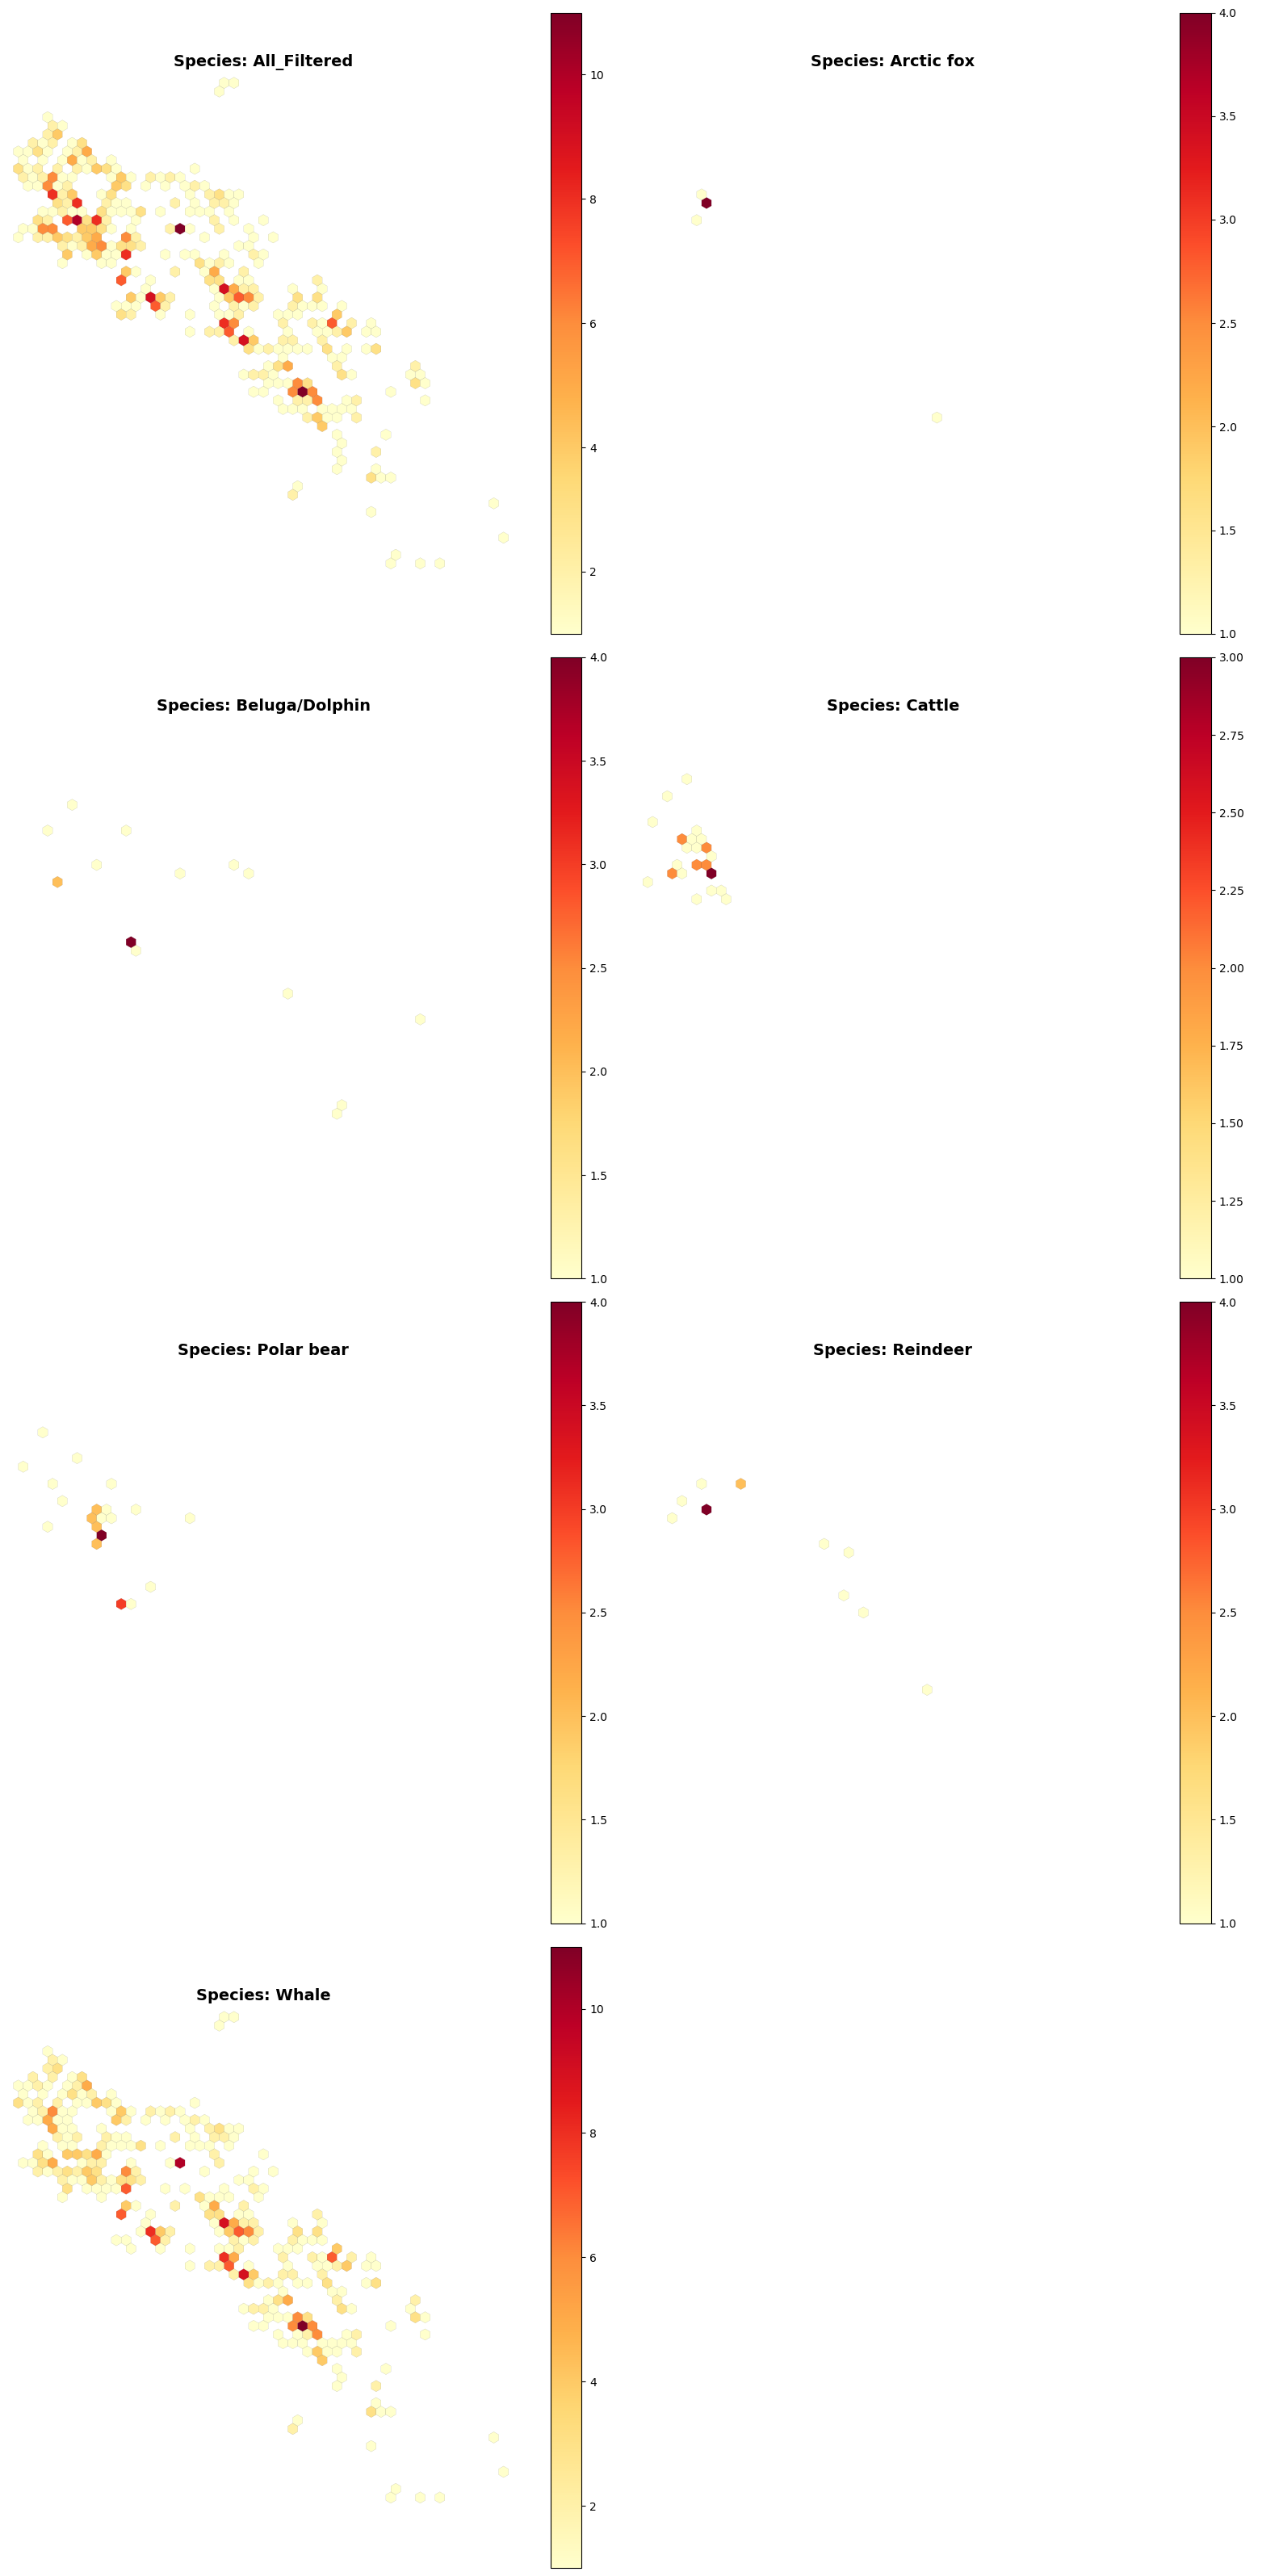

In [15]:
import geopandas as gpd
import sys
if 'ipykernel' not in sys.modules:
    import matplotlib
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import pyogrio
import math
from shapely.geometry import Polygon as ShapelyPolygon

# =================================================================
# 1. CONFIGURATION
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    # Look for sibling directory '../GAS_stats'
    sibling_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'GAS_stats'))
    if os.path.exists(sibling_path):
        base_path = sibling_path
    else:
        base_path = os.getcwd()
input_name = 'GAS_unified.gpkg'
output_name = 'Gashamna_Hexbin_Analysis.gpkg'
output_image_name = 'Gashamna_Hexbin_Overview.png'

original_gpkg = os.path.join(base_path, input_name)
output_gpkg = os.path.join(base_path, output_name)
output_image = os.path.join(base_path, output_image_name)

grid_res = 50        
color_map = 'YlOrRd' 
min_individuals = 5  
# =================================================================
# 2. FIXED HEXAGON LOGIC
# =================================================================
def generate_hex_layer_fixed(gdf, species_col, global_extent, spec_filter=None):
    data = gdf[gdf[species_col] == spec_filter] if spec_filter else gdf
    if data.empty: return None

    # We use a dummy figure to calculate the grid based on the GLOBAL extent
    fig_temp, ax_temp = plt.subplots()
    ax_temp.set_aspect('equal')  # Prevent shape distortion
    hb = ax_temp.hexbin(
        data.geometry.x, 
        data.geometry.y, 
        gridsize=grid_res, 
        mincnt=1,
        extent=global_extent  # Critical: Keeps the grid alignment identical
    )
    
    offsets, paths, counts = hb.get_offsets(), hb.get_paths()[0], hb.get_array()
    plt.close(fig_temp)

    geoms = [ShapelyPolygon(paths.vertices + offset) for offset in offsets]
    return gpd.GeoDataFrame({'count': counts, 'species': str(spec_filter) or 'All'}, 
                             geometry=geoms, crs=gdf.crs)

# =================================================================
# 3. PROCESSING
# =================================================================
if not os.path.exists(original_gpkg):
    print(f"Error: {input_name} not found.")
else:
    layers = pyogrio.list_layers(original_gpkg)
    all_points = gpd.read_file(original_gpkg, layer=layers[0][0])
    species_col = next((c for c in ['species', 'species_clean', 'Art'] if c in all_points.columns), 'species')
    
    # 3.1 Calculate Reference Bounds (Global)
    total_bounds = all_points.total_bounds 
    # Matplotlib extent: (xmin, xmax, ymin, ymax)
    m_extent = (total_bounds[0], total_bounds[2], total_bounds[1], total_bounds[3])
    
    # 3.2 Run Calculations
    counts = all_points[species_col].value_counts()
    valid_species = counts[counts >= min_individuals].index.tolist()
    
    hex_results = {'All_Filtered': generate_hex_layer_fixed(all_points, species_col, m_extent)}
    for spec in sorted(valid_species):
        hex_results[spec] = generate_hex_layer_fixed(all_points, species_col, m_extent, spec)

    # =================================================================
    # 4. PLOTTING WITH FIXED AXES (Uniform Scale)
    # =================================================================
    n_plots = len(hex_results)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 8 * rows))
    axes = axes.flatten()

    for i, (name, gdf) in enumerate(hex_results.items()):
        if gdf is not None:
            # Plot the hexagons
            gdf.plot(ax=axes[i], column='count', cmap=color_map, legend=True,
                     edgecolor='black', linewidth=0.05)
            
            # CRITICAL: Force every subplot to show the exact same geographical area
            axes[i].set_xlim(total_bounds[0] - 5, total_bounds[2] + 5)
            axes[i].set_ylim(total_bounds[1] - 5, total_bounds[3] + 5)
            
            axes[i].set_title(f"Species: {name}", fontsize=14, fontweight='bold')
            axes[i].set_aspect('equal')
            axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    
    # Export GPKG layers
    if os.path.exists(output_gpkg): os.remove(output_gpkg)
    for name, gdf in hex_results.items():
        if gdf is not None:
            gdf.to_file(output_gpkg, layer=f"Hex_{name.replace(' ', '_')}", driver="GPKG")

    print(f"Success: Analysis with uniform scaling finished.")
    plt.show()
